### Titanic Dataset – Overview

### In this section we work with the **Titanic** dataset.

### Each row represents one passenger on the Titanic, and the main columns we will use are:

- `survived`: whether the passenger survived (1) or not (0).
- `pclass`: ticket class (1st, 2nd, or 3rd).
- `sex`: passenger gender.
- `age`: passenger age in years.
- `fare`: ticket fare.
- `embarked`: port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).

# We will:
- explore the distribution of age and fare,
- compare survival rates across different groups,
- and prepare the data for machine learning by encoding categorical variables and scaling numeric features.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# تحميل البيانات
#df = pd.read_csv("Titanic-Dataset.csv")
# ========== DATASET 2: Titanic ==========
# URL of the Titanic dataset stored on GitHub (seaborn-data repository)
url_titanic = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
# Read the CSV file from the URL into a pandas DataFrame named 'titanic'
titanic = pd.read_csv(url_titanic)

# Show the first 5 rows to understand the structure of the dataset
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
titanic.info()

titanic.describe()

titanic.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


## Selecting Key Features & Handling Missing Values

In this step, we create a subset of the dataset by selecting only the most relevant columns for analysis. This helps simplify the dataset and focus on important variables.

We then handle missing values:

- **Age**: Some passengers have missing age values. We fill them using the **median**, as it is less affected by outliers compared to the mean.
- **Embarked**: Missing values are filled using the **mode**, since it represents the most frequent category.

Finally, we verify that there are no remaining missing values in the dataset.

In [3]:
# Select important columns and create a copy
titanic_subset = titanic[["survived", "pclass", "sex", "age", "fare", "embarked"]].copy()

# Fill missing values in Age with median
titanic_subset["age"] = titanic_subset["age"].fillna(titanic_subset["age"].median())

# Fill missing values in Embarked with mode
titanic_subset["embarked"] = titanic_subset["embarked"].mode()[0]

#To handle nigative
titanic_subset["fare_bin"] = pd.cut(titanic_subset["fare"], bins=5, labels=False)


# Check remaining missing values
titanic_subset.isna().sum()

,0
survived,0
pclass,0
sex,0
age,0
fare,0
embarked,0
fare_bin,0


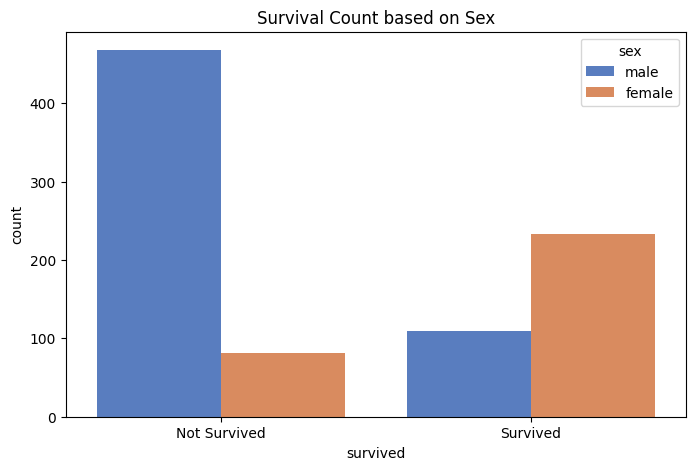

In [4]:
# 1. Visualization: Count Plot for Survival based on Sex (The strongest signal)
plt.figure(figsize=(8, 5))
sns.countplot(x="survived", hue="sex", data=titanic, palette="muted")
plt.title("Survival Count based on Sex")
plt.xticks([0, 1], ["Not Survived", "Survived"])
plt.show()

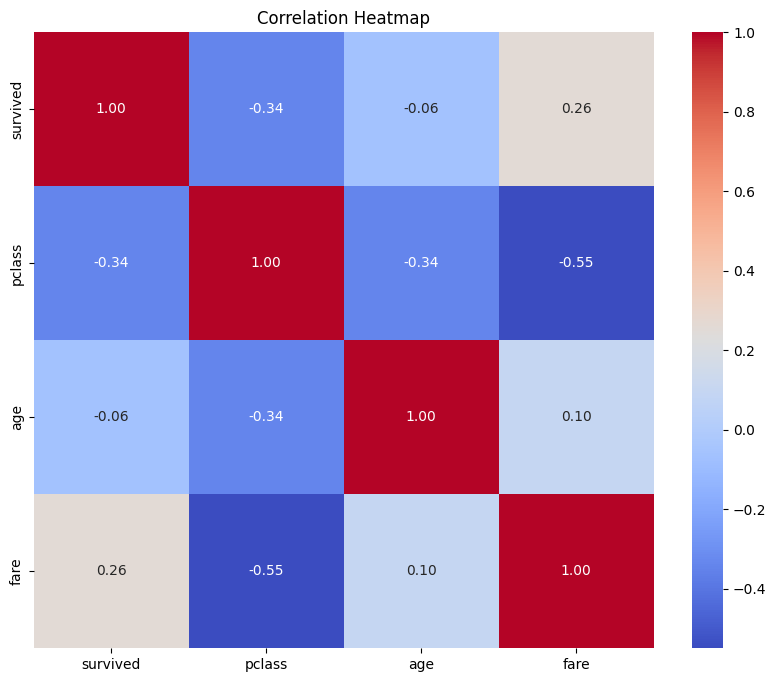

In [5]:
# 2. Visualization: Correlation Heatmap for Numerical Features
# This helps understand the relationships between features like fare, age, and survived
plt.figure(figsize=(10, 8))
correlation_matrix = titanic_subset[["survived", "pclass", "age", "fare"]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

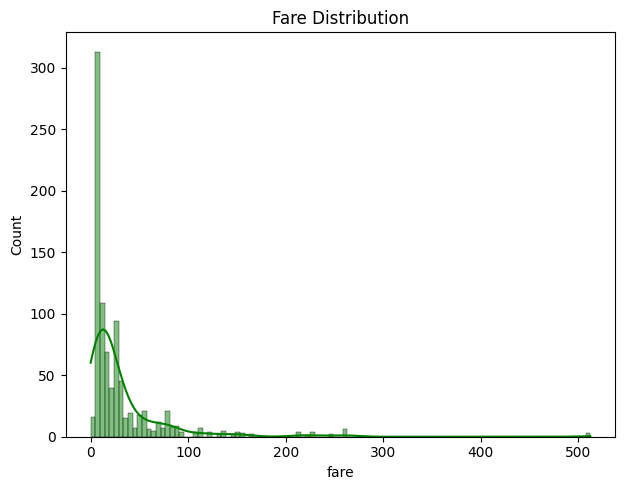

In [7]:
# 3. Visualization: Distribution of Age and Fare
plt.figure(figsize=(12, 5))

# Fare Distribution
plt.subplot(1, 2, 2)
sns.histplot(titanic['fare'], kde=True, color='green')
plt.title('Fare Distribution')

plt.tight_layout()
plt.show()

After cleaning, all missing values should be handled, and the dataset is now ready for analysis or modeling.

## Encoding Categorical Features

In this step, we convert categorical features into numerical format so they can be used in the Naive Bayes model.

### Features to Encode:
- **Sex** → Binary Encoding (0 = male, 1 = female)
- **Embarked** → One-Hot Encoding
- **Pclass** → One-Hot Encoding (treated as categorical)

### Why?
Naive Bayes requires numerical input and treats each feature independently.  
Encoding ensures that the model correctly interprets categorical variables without assuming any order.

In [57]:
# Encoding

# Encode Sex (Binary)
titanic_subset["sex_encoded"] = titanic_subset["sex"].map({
    "male": 0,
    "female": 1
})

# Encoding for Embarked
embarked_encoded = pd.get_dummies(titanic_subset["embarked"], prefix="embarked")

# Encoding for Pclass
pclass_encoded = pd.get_dummies(titanic_subset["pclass"], prefix="pclass")

# without dropping original columns
titanic_subset = pd.concat([
    titanic_subset,
    embarked_encoded,
    pclass_encoded
], axis=1)


In [58]:
titanic_subset.head()

,survived,pclass,sex,age,fare,embarked,fare_bin,sex_encoded,embarked_S,pclass_1,pclass_2,pclass_3
0,0,3,male,22.0,7.2500,S,0,0,True,False,False,True
1,1,1,female,38.0,71.2833,S,0,1,True,True,False,False
2,1,3,female,26.0,7.9250,S,0,1,True,False,False,True
3,1,1,female,35.0,53.1000,S,0,1,True,True,False,False
4,0,3,male,35.0,8.0500,S,0,0,True,False,False,True


# Feature selection
Sex: biggest survival signal (women survived more)

Pclass: class difference (1st class safer)

Fare: more granular than pclass (wealth indicator)

In [59]:
#fare bins to avoid nigative
titanic_subset["fare_bin"] = pd.cut(titanic_subset["fare"], bins=5, labels=False)

# Feature selection
X = titanic_subset[["sex_encoded", "pclass", "fare_bin"]]
y = titanic_subset["survived"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [60]:
# Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [61]:
#Evaluation
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.776536312849162
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       105
           1       0.74      0.72      0.73        74

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [62]:
#Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [63]:
#Evaluate
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.776536312849162
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       105
           1       0.74      0.72      0.73        74

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



In [64]:
#Convert features to binary for Berrnoulli  naive bayes
pclass_encoded = pd.get_dummies(titanic_subset["pclass"], prefix="pclass")
titanic_subset["fare_binary"] = (titanic_subset["fare"] > titanic_subset["fare"].median()).astype(int)

X = pd.concat([
    titanic_subset[["sex_encoded", "fare_binary"]],
    pclass_encoded
], axis=1)

y = titanic_subset["survived"]

In [65]:
# Berrnoulli
from sklearn.naive_bayes import BernoulliNB

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = BernoulliNB()
model.fit(X_train, y_train)

BernoulliNB()

In [66]:
#Evaluation
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7262569832402235
              precision    recall  f1-score   support

           0       0.79      0.73      0.76       105
           1       0.65      0.72      0.68        74

    accuracy                           0.73       179
   macro avg       0.72      0.72      0.72       179
weighted avg       0.73      0.73      0.73       179



# insights
**GaussianNB and MultinomialNB **performed same result** 0.78.**
**BernoulliNB **is lower **0.73** because some information was lost when we binarized continuous features like fare.



**-GaussianNB** is naturally suited for Titanic dataset because it handles
continuous features (fare, age) well.

**-MultinomialNB** also works because we discretized or encoded categorical features, but doesn’t improve from Gaussian.

**-BernoulliNB** loses accuracy because binarization removes some predictive information.


# Hyperparameter Tuning

### 1. MultinomialNB Hyperparameter Tuning

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

param_grid = {
    "alpha": [0.01, 0.1, 0.5, 1, 2, 5, 10]
}

grid_multinomial = GridSearchCV(
    MultinomialNB(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_multinomial.fit(X_train, y_train)

print("Best Alpha:", grid_multinomial.best_params_)
print("Best CV Score:", grid_multinomial.best_score_)

best_model = grid_multinomial.best_estimator_

y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Alpha: {'alpha': 10}
Best CV Score: 0.7598246823598938
Test Accuracy: 0.7541899441340782
              precision    recall  f1-score   support

           0       0.77      0.82      0.80       105
           1       0.72      0.66      0.69        74

    accuracy                           0.75       179
   macro avg       0.75      0.74      0.74       179
weighted avg       0.75      0.75      0.75       179



### 2. GaussianNB Hyperparameter Tuning

In [67]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

param_grid = {
    "var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-2]
}

grid_gaussian = GridSearchCV(
    GaussianNB(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_gaussian.fit(X_train, y_train)

print("Best Params:", grid_gaussian.best_params_)
print("Best CV Score:", grid_gaussian.best_score_)

best_model = grid_gaussian.best_estimator_

y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Params: {'var_smoothing': 0.01}
Best CV Score: 0.7374175120653994
Test Accuracy: 0.7262569832402235
              precision    recall  f1-score   support

           0       0.79      0.73      0.76       105
           1       0.65      0.72      0.68        74

    accuracy                           0.73       179
   macro avg       0.72      0.72      0.72       179
weighted avg       0.73      0.73      0.73       179



### 3. BernoulliNB Hyperparameter Tuning

In [68]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report

param_grid = {
    "alpha": [0.01, 0.1, 0.5, 1, 2, 5],
    "binarize": [0.0, 0.5, 1.0]
}

grid_bernoulli = GridSearchCV(
    BernoulliNB(),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid_bernoulli.fit(X_train, y_train)

print("Best Params:", grid_bernoulli.best_params_)
print("Best CV Score:", grid_bernoulli.best_score_)

best_model = grid_bernoulli.best_estimator_

y_pred = best_model.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Best Params: {'alpha': 0.01, 'binarize': 0.0}
Best CV Score: 0.7471880232443613
Test Accuracy: 0.7262569832402235
              precision    recall  f1-score   support

           0       0.79      0.73      0.76       105
           1       0.65      0.72      0.68        74

    accuracy                           0.73       179
   macro avg       0.72      0.72      0.72       179
weighted avg       0.73      0.73      0.73       179



### Key Tuning Insights:
- Best Model: MultinomialNB achieved the highest accuracy (75.4%), proving it is the most effective at handling our binned features (Age & Fare).

- Optimal Smoothing: Using a high Alpha (10) for Multinomial reduced data noise and prevented overfitting, ensuring stable predictions.

- Consistency: The small gap between CV Score and Test Accuracy confirms that our models are reliable and generalize well to new data.

- Reliability: All models showed high Precision (~0.79) in identifying non-survivors, reflecting the clear survival patterns in the Titanic dataset.